In [1]:
import MDAnalysis as mda
import MDAnalysis.analysis.pca as pca
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nglview as nv

In [2]:
u = mda.Universe("../workspace/apo/ff19sb/opc/1/minimized.pdb", "../workspace/apo/ff19sb/opc/1/production.dcd", in_memory=True)

/public/groups/frueh/jaanderson/miniconda3/envs/openmm/lib/python3.13/site-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element EP found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/public/groups/frueh/jaanderson/miniconda3/envs/openmm/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [3]:
pc = pca.PCA(u, select='backbone',
             align=False, mean=None,
             n_components=None, verbose=True).run()

Mean Calculation:   0%|          | 0/52500 [00:00<?, ?it/s]

  0%|          | 0/52500 [00:00<?, ?it/s]

In [4]:
for i in range(5):
    print(f"The first {i} component(s) accounts for {100*pc.results.cumulated_variance[i]:.1f}% of the variance.")

The first 0 component(s) accounts for 47.4% of the variance.
The first 1 component(s) accounts for 71.5% of the variance.
The first 2 component(s) accounts for 87.1% of the variance.
The first 3 component(s) accounts for 90.1% of the variance.
The first 4 component(s) accounts for 92.7% of the variance.


In [5]:
backbone = u.select_atoms('backbone')
transformed = pc.transform(backbone, n_components=3)

In [6]:
df = pd.DataFrame(transformed,
                  columns=['PC{}'.format(i+1) for i in range(3)])
df['Time (ps)'] = df.index * u.trajectory.dt
df.head()

,PC1,PC2,PC3,Time (ps)
0,-120.588082,237.638012,29.245588,0.0
1,-115.191650,239.582234,22.913643,20.0
2,-117.347719,236.221085,23.302717,40.0
3,-110.646813,237.428299,21.036254,60.0
4,-103.782970,236.390468,20.122685,80.0


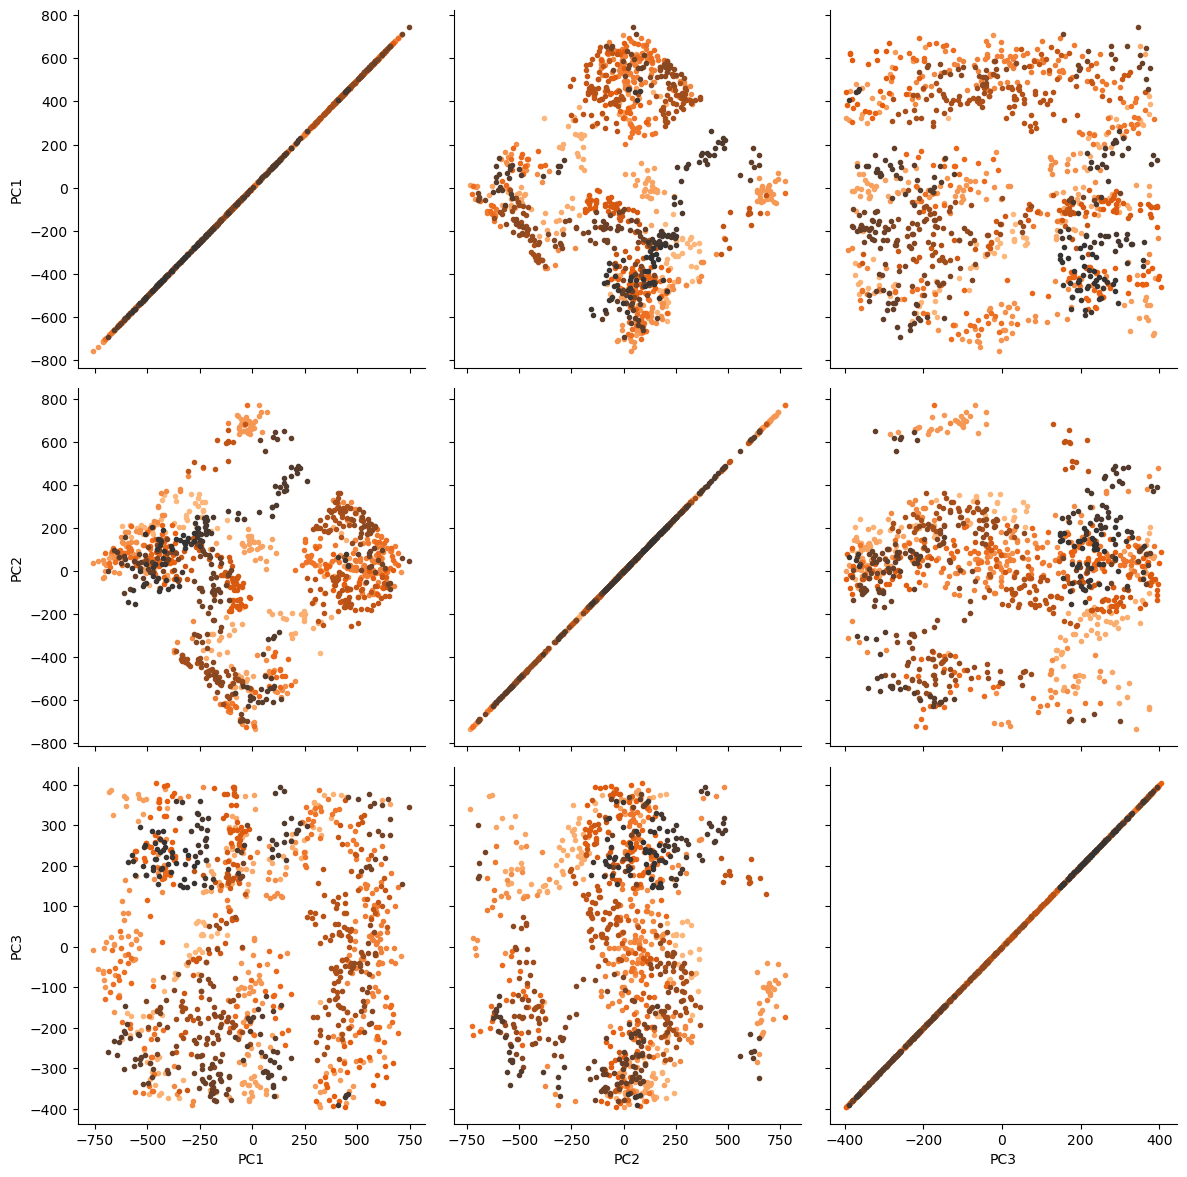

In [7]:
g = sns.PairGrid(df[::50], hue='Time (ps)',
                 palette=sns.color_palette('Oranges_d',
                 n_colors=len(df[::50])),
                 height=4
                )
g.map(plt.scatter, marker='.')
g.savefig("PCA.png")
plt.show()

In [8]:
pc1 = pc.p_components[:, 0]
trans1 = transformed[:, 0]
projected = np.outer(trans1, pc1) + pc.mean.flatten()
coordinates = projected.reshape(len(trans1), -1, 3)

/public/groups/frueh/jaanderson/miniconda3/envs/openmm/lib/python3.13/site-packages/MDAnalysis/analysis/pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


In [9]:
proj1 = mda.Merge(backbone)
proj1.load_new(coordinates, order="fac")

<Universe with 326 atoms>